In [36]:

from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor

random_state = 42
np.random.seed(random_state)

In [37]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('processed_player_data_v2.csv')

df.head()

,Game ID,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss,time_control,time_control_encoded,player_username,opponent_username,opening_familiarity,player_rapid_rating,opponent_rapid_rating,player_rapid_games,opponent_rapid_games,player_blitz_rating,opponent_blitz_rating,player_blitz_games,opponent_blitz_games,player_bullet_rating,opponent_bullet_rating,player_bullet_games,opponent_bullet_games,player_total_games,opponent_total_games,player_play_time_secs,opponent_play_time_secs,player_avg_game_secs,opponent_avg_game_secs,player_blitz_vs_rapid,player_bullet_vs_blitz,player_bullet_vs_rapid,opponent_blitz_vs_rapid,opponent_bullet_vs_blitz,opponent_bullet_vs_rapid,player_rapid_ratio,player_blitz_ratio,player_bullet_ratio,opponent_rapid_ratio,opponent_blitz_ratio,opponent_bullet_ratio,rapid_rating_gap,blitz_rating_gap,total_games_gap,rapid_games_gap,play_time_gap
0,J7Xvjkte,1441,1559,1,4,-0.078667,2,32,87,rapid,3,jerzypa2,timothei,1,1467.0,1659.0,965,2657,1155.0,1385.0,142,952,982.0,1018.0,26,8,1251,3980,1016708,3090613,812.716227,776.535930,-312.0,-173.0,-485.0,-274.0,-367.0,-641.0,0.771383,0.113509,0.020783,0.667588,0.239196,0.002010,-192.0,-230.0,-2729,-1692,-2073905
1,SSzpi7W1,1258,1567,1,6,-0.218761,2,43,6,rapid,3,nephi,veky,1,1221.0,1689.0,261,3466,1184.0,1393.0,6,9327,1284.0,1500.0,3,4452,333,18177,272224,6513529,817.489489,358.339055,-37.0,100.0,63.0,-296.0,107.0,-189.0,0.783784,0.018018,0.009009,0.190681,0.513121,0.244925,-468.0,-209.0,-17844,-3205,-6241305
2,NHpcYm3r,1697,1712,1,7,-0.008800,2,11,42,rapid,3,ronuh,kuramateca,1,NaN,1573.0,0,9230,NaN,1357.0,0,119,NaN,1330.0,0,2,0,9358,0,7732082,NaN,826.253687,NaN,NaN,NaN,-216.0,-27.0,-243.0,NaN,NaN,NaN,0.986322,0.012716,0.000214,NaN,NaN,-9358,-9230,-7732082
3,Nrzmgzmn,1978,1868,1,5,0.057202,2,21,53,rapid,3,anaya44,jeoda,1,NaN,1786.0,0,2172,NaN,1640.0,0,29436,NaN,955.0,0,1,0,31613,0,16836309,NaN,532.575491,NaN,NaN,NaN,-146.0,-685.0,-831.0,NaN,NaN,NaN,0.068706,0.931136,0.000032,NaN,NaN,-31613,-2172,-16836309
4,xMuFsnC6,2073,1816,1,2,0.132168,2,35,50,rapid,3,marc_robin,deraincharles,1,2158.0,2029.0,226,790,2119.0,1841.0,31948,2351,1500.0,1609.0,0,1357,32177,4567,14125375,1843793,438.989806,403.720823,-39.0,-619.0,-658.0,-188.0,-232.0,-420.0,0.007024,0.992883,0.000000,0.172980,0.514780,0.297132,129.0,278.0,27610,-564,12281582


In [38]:
numeric_cols     = df.select_dtypes(include='number').columns.tolist()
non_numeric_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  {col}  [{df[col].dtype}]  nulls: {df[col].isnull().sum()}")

print(f"\nNon-numeric columns ({len(non_numeric_cols)}):")
for col in non_numeric_cols:
    print(f"  {col}  [{df[col].dtype}]  nulls: {df[col].isnull().sum()}  unique: {df[col].nunique()}")

Numeric columns (45):
  player_rating  [int64]  nulls: 0
  opponent_rating  [int64]  nulls: 0
  player_white  [int64]  nulls: 0
  opening_ply  [int64]  nulls: 0
  elo_delta_ratio  [float64]  nulls: 0
  opening_frequency  [int64]  nulls: 0
  player_centipawn_loss  [int64]  nulls: 0
  opponent_centipawn_loss  [int64]  nulls: 0
  time_control_encoded  [int64]  nulls: 0
  opening_familiarity  [int64]  nulls: 0
  player_rapid_rating  [float64]  nulls: 5650
  opponent_rapid_rating  [float64]  nulls: 5650
  player_rapid_games  [int64]  nulls: 0
  opponent_rapid_games  [int64]  nulls: 0
  player_blitz_rating  [float64]  nulls: 5650
  opponent_blitz_rating  [float64]  nulls: 5650
  player_blitz_games  [int64]  nulls: 0
  opponent_blitz_games  [int64]  nulls: 0
  player_bullet_rating  [float64]  nulls: 5650
  opponent_bullet_rating  [float64]  nulls: 5650
  player_bullet_games  [int64]  nulls: 0
  opponent_bullet_games  [int64]  nulls: 0
  player_total_games  [int64]  nulls: 0
  opponent_total_g

In [39]:
null_stat_players = df[df['player_rapid_rating'].isnull()]['player_username'].dropna().unique()
print(f"Example usernames with null stats (deleted/banned accounts ?):")
for u in null_stat_players[:5]:
    print(f"  {u}")

#This is the return value when queries for one of the users.

#{"id":"jacobboehme","username":"JacobBoehme","disabled":true} <= we don't know why the account is closed


Example usernames with null stats (deleted/banned accounts ?):
  ronuh
  anaya44
  lordofking
  rodolfos
  jacobboehme


I have 37274 rows, highest null count is 10328.
Null values are typically in columns related to rating
I am thkinking of these options:
-Fill in the missing data
-Drop all of the rows that have null, if I would drop these rows I would lose 1/4 of the data
-Drop the columns with 25% missing data
-Maybe make a feature out of missing data ?

My assumption is that missing data is due to the closure of account. 
Accounts can be closed manually or banned due to cheating.

According to the presentations in 04_Data_preparation is data MNAR or MAR ?
For cheaters I guess so, as cheater will probably have higher elo.



In [40]:
# We do not need gamed id, player usernames and time control for our analysis, so we can drop those columns. Time control is encoded in time control encoded, but since it has only 1 unique value, we can drop it as well.
df = df.drop(columns=['Game ID', 'player_username', 'opponent_username', 'time_control','time_control_encoded','opponent_centipawn_loss'])

#Should I also drop opponent centipawn loss ? it highly correlated to player centipawn loss.
#Based on business logic I will drop it. 

Also if player profile is disabled, other columns are influenced like total games (fetching script assumes then that total games are 0)

After considering couple of options of dropping or not dropping. I will make a feature called player_profile_disabled or something like that. I will just handle the missing data by imputing the median. This data will be served into my first iteration of models.

In [41]:
rating_cols = ['player_rapid_rating', 'player_blitz_rating', 'player_bullet_rating']
opponent_rating_cols = ['opponent_rapid_rating', 'opponent_blitz_rating', 'opponent_bullet_rating']

df['player_profile_disabled']   = df[rating_cols].isnull().any(axis=1).astype(int)
df['opponent_profile_disabled']  = df[opponent_rating_cols].isnull().any(axis=1).astype(int)

print(f"player_profile_disabled: {df['player_profile_disabled'].sum()}  active: {(df['player_profile_disabled']==0).sum()}")
print(f"opponent_profile_disabled: {df['opponent_profile_disabled'].sum()}  active: {(df['opponent_profile_disabled']==0).sum()}")

player_profile_disabled: 5650  active: 31624
opponent_profile_disabled: 5650  active: 31624


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37274 entries, 0 to 37273
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   player_rating              37274 non-null  int64  
 1   opponent_rating            37274 non-null  int64  
 2   player_white               37274 non-null  int64  
 3   opening_ply                37274 non-null  int64  
 4   elo_delta_ratio            37274 non-null  float64
 5   opening_frequency          37274 non-null  int64  
 6   player_centipawn_loss      37274 non-null  int64  
 7   opening_familiarity        37274 non-null  int64  
 8   player_rapid_rating        31624 non-null  float64
 9   opponent_rapid_rating      31624 non-null  float64
 10  player_rapid_games         37274 non-null  int64  
 11  opponent_rapid_games       37274 non-null  int64  
 12  player_blitz_rating        31624 non-null  float64
 13  opponent_blitz_rating      31624 non-null  flo

In [43]:
X = df.drop(columns=['player_centipawn_loss'])
y = df['player_centipawn_loss']

In [44]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [45]:
X_train.columns

Index(['player_rating', 'opponent_rating', 'player_white', 'opening_ply',
       'elo_delta_ratio', 'opening_frequency', 'opening_familiarity',
       'player_rapid_rating', 'opponent_rapid_rating', 'player_rapid_games',
       'opponent_rapid_games', 'player_blitz_rating', 'opponent_blitz_rating',
       'player_blitz_games', 'opponent_blitz_games', 'player_bullet_rating',
       'opponent_bullet_rating', 'player_bullet_games',
       'opponent_bullet_games', 'player_total_games', 'opponent_total_games',
       'player_play_time_secs', 'opponent_play_time_secs',
       'player_avg_game_secs', 'opponent_avg_game_secs',
       'player_blitz_vs_rapid', 'player_bullet_vs_blitz',
       'player_bullet_vs_rapid', 'opponent_blitz_vs_rapid',
       'opponent_bullet_vs_blitz', 'opponent_bullet_vs_rapid',
       'player_rapid_ratio', 'player_blitz_ratio', 'player_bullet_ratio',
       'opponent_rapid_ratio', 'opponent_blitz_ratio', 'opponent_bullet_ratio',
       'rapid_rating_gap', 'blitz_rati



Handling Missing Values
For now I'll just use median. I'll explore other techniques later.

Skewness

Scaling 
For now I'll just use Standard Scaler.

In [46]:


baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression()),
])

baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [47]:
y_pred_train = baseline_pipeline.predict(X_train)
y_pred_val   = baseline_pipeline.predict(X_val)

train_mse = mean_squared_error(y_train, y_pred_train)
val_mse   = mean_squared_error(y_val,   y_pred_val)

print(f"Baseline Linear Regression")
print(f"  Train MSE: {train_mse:.2f}   RMSE: {np.sqrt(train_mse):.2f}")
print(f"  Val   MSE: {val_mse:.2f}   RMSE: {np.sqrt(val_mse):.2f}")

Baseline Linear Regression
  Train MSE: 1216.86   RMSE: 34.88
  Val   MSE: 1232.42   RMSE: 35.11


In [48]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_mse = mean_squared_error(y_val, dummy.predict(X_val))
print(f"Dummy (mean) RMSE: {np.sqrt(dummy_mse):.2f}")

Dummy (mean) RMSE: 37.61


# TODO What am I missing
Handle skewness

Check distrbution of each feature and check if it follows distribution that will be present in production ?

Explore different techniques of handling missing values

Make graphs 1:1 feature vs feature, maybe it can show intresting relationships

Make more advanced model exploration

Hyperparameter tuning

Consider using clustering


# Baseline 

Baseline Model/Dummy to beat:

Simple Linear Regression: 
  Train MSE: 1216.86   RMSE: 34.88
  Val   MSE: 1232.42   RMSE: 35.11

Dummy (mean) RMSE: 37.61


# Model Exploration

In [49]:
kf = KFold(n_splits=5, shuffle=True)

In [50]:

def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')), #I'll use median for now
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])

potential_models = {
    'Dummy':              make_pipeline(DummyRegressor(strategy='mean')),
    'Linear Regression':  make_pipeline(LinearRegression()),
    'Ridge':              make_pipeline(Ridge(alpha=1.0)),
    'Lasso':              make_pipeline(Lasso(alpha=0.1)),
    'ElasticNet':         make_pipeline(ElasticNet(alpha=0.1, l1_ratio=0.5)),
    'KNN (k=10)':         make_pipeline(KNeighborsRegressor(n_neighbors=10)),
    'Decision Tree':      make_pipeline(DecisionTreeRegressor(random_state=random_state)),
    'Random Forest':      make_pipeline(RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)),
    'Gradient Boosting':  make_pipeline(GradientBoostingRegressor(n_estimators=200, random_state=random_state)),
}

results = {}

for name, model_pipeline in potential_models.items():
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    results[name] = {'mse': mse, 'rmse': rmse}
    print(f"{name:<22}  Val MSE: {mse:.2f}   RMSE: {rmse:.2f}")

results_df = pd.DataFrame(results).T.sort_values('rmse')
print("\n---Ranking ---")
print(results_df.to_string())


Dummy                   Val MSE: 1414.51   RMSE: 37.61
Linear Regression       Val MSE: 1232.42   RMSE: 35.11
Ridge                   Val MSE: 1232.39   RMSE: 35.11
Lasso                   Val MSE: 1233.35   RMSE: 35.12
ElasticNet              Val MSE: 1233.81   RMSE: 35.13
KNN (k=10)              Val MSE: 1323.06   RMSE: 36.37
Decision Tree           Val MSE: 2441.69   RMSE: 49.41
Random Forest           Val MSE: 1205.21   RMSE: 34.72
Gradient Boosting       Val MSE: 1194.06   RMSE: 34.56

---Ranking ---
                           mse       rmse
Gradient Boosting  1194.059657  34.555168
Random Forest      1205.211095  34.716150
Ridge              1232.392498  35.105448
Linear Regression  1232.415256  35.105772
Lasso              1233.354761  35.119151
ElasticNet         1233.805844  35.125573
KNN (k=10)         1323.064683  36.373956
Dummy              1414.513142  37.610014
Decision Tree      2441.688548  49.413445


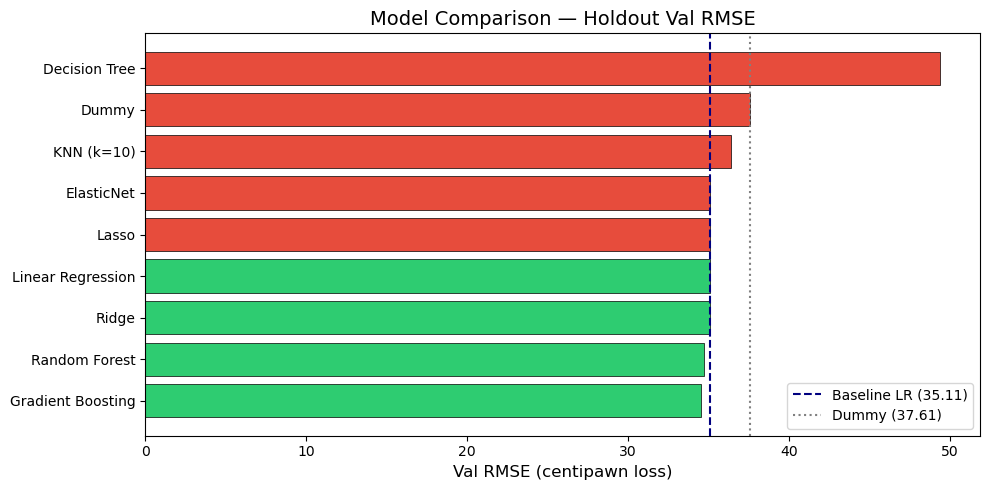

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if r < 35.11 else '#e74c3c' for r in results_df['rmse']]
bars = ax.barh(results_df.index, results_df['rmse'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(35.11, color='navy', linestyle='--', linewidth=1.5, label='Baseline LR (35.11)')
ax.axvline(37.61, color='gray', linestyle=':', linewidth=1.5, label='Dummy (37.61)')
ax.set_xlabel('Val RMSE (centipawn loss)', fontsize=12)
ax.set_title('Model Comparison — Holdout Val RMSE', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


Feature importance via: Gradient Boosting


C:\Users\mikol\AppData\Local\Temp\ipykernel_37488\313415186.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', ax=ax, palette='viridis')


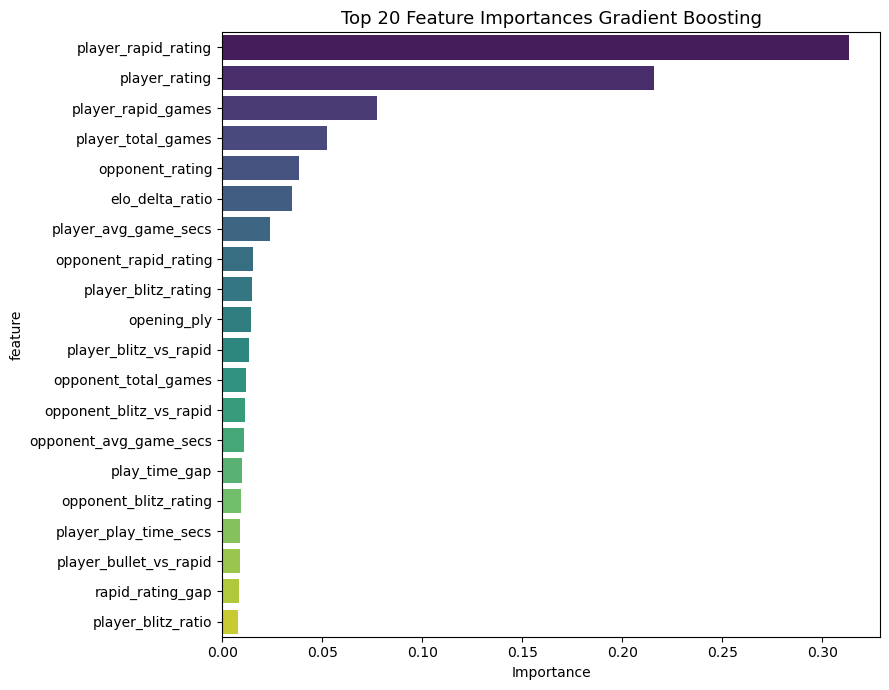

                feature  importance
    player_rapid_rating    0.313224
          player_rating    0.215678
     player_rapid_games    0.077591
     player_total_games    0.052187
        opponent_rating    0.038187
        elo_delta_ratio    0.034745
   player_avg_game_secs    0.023788
  opponent_rapid_rating    0.015315
    player_blitz_rating    0.014890
            opening_ply    0.014492
  player_blitz_vs_rapid    0.013524
   opponent_total_games    0.012131
opponent_blitz_vs_rapid    0.011455
 opponent_avg_game_secs    0.010944
          play_time_gap    0.009846
  opponent_blitz_rating    0.009596
  player_play_time_secs    0.009152
 player_bullet_vs_rapid    0.009008
       rapid_rating_gap    0.008587
     player_blitz_ratio    0.007839


In [52]:

FEAT_IMP_MODELS = ['Gradient Boosting', 'Random Forest']

best_fi_name = next((m for m in results_df.index if m in FEAT_IMP_MODELS), None)

if best_fi_name:
    print(f"Feature importance via: {best_fi_name}")
    pipe = potential_models[best_fi_name]
    pipe.fit(X_train_val, y_train_val)
    importances = pipe.named_steps['model'].feature_importances_
    feat_names = X_train_val.columns.tolist()

    fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.barplot(data=fi_df, x='importance', y='feature', ax=ax, palette='viridis')
    ax.set_title(f'Top 20 Feature Importances {best_fi_name}', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(fi_df.to_string(index=False))
else:
    from sklearn.inspection import permutation_importance
    print(f"Using permutation importance for: {results_df.index[0]}")
    best_pipe = potential_models[results_df.index[0]]
    best_pipe.fit(X_train, y_train)
    r = permutation_importance(best_pipe, X_val, y_val, n_repeats=10,
                               random_state=random_state, scoring='neg_root_mean_squared_error')
    fi_df = pd.DataFrame({'feature': X_val.columns,
                          'importance': r.importances_mean})
    fi_df = fi_df.sort_values('importance', ascending=False).head(20)
    print(fi_df.to_string(index=False))


Best Models: <br>
-Gradient Boosting <br>
-Random Forest <br>
-Ridge <br>

Next steps: <br>
-Handle skewness <br> 
-Try alternative imputation <br>
-Consider feature selection <br>
-Add interaction features <br>

The most promising models are : Gradient Boosting, Random Forest and Ridge. <br>
The next steps would be to see whether different imputing strategy would improve the model. <br>
I'll also do hyperparameter tuning to see whether I can yield some results. <br>
I'll also use Cross-Validation. <br>

Check if changing the imputing strategy yields any results

In [54]:
pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)), 
        ('scaler',  StandardScaler()),
        ('model',   GradientBoostingRegressor(n_estimators=200, random_state=random_state)),
    ])


pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print(f"Val MSE: {mse:.2f}   RMSE: {rmse:.2f}")

Val MSE: 1197.22   RMSE: 34.60


Using KNN Imputer actually made RMSE compared to the "default" setup which is Imputing Median

# HyperParameter Tuning

I'll use RandomizedSearchCV as when I run GridSearchCV it is too slow.

In [ ]:
pipeline = Pipeline([ 
        ('scaler',  StandardScaler()),        
        # Based on my HistGradientBoostingRegressor handles NaNs internally that's why I will not use imputer here. 
        ('model',   HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
    ])

param_dist = {
    'model__max_iter':      randint(100, 400),  
    'model__max_depth':     randint(3, 8),
    'model__learning_rate': uniform(0.01, 0.3),
}

search = RandomizedSearchCV(pipeline, param_dist, n_iter=30, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)

search.fit(X_train, y_train) 

print(search.best_params_)
print(-search.best_score_)

y_pred = search.best_estimator_.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
print(f"Val RMSE: {np.sqrt(mse):.2f}")

{'model__learning_rate': np.float64(0.0330939729486379), 'model__max_depth': 5, 'model__max_iter': 342}
34.24350774436418
Val RMSE: 34.33


RMSE on hyperparameter-tuned GradientBoostingModel improved by 34.555168 - 34.33 ~= 0.22 centipawn